In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!unzip -q /content/drive/MyDrive/Luna16.zip

In [ ]:
!pip install -q tensorflow scikit-learn pandas numpy matplotlib joblib streamlit pyngrok

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 18.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 124.4 MB/s eta 0:00:00


In [ ]:
# Import all required libraries
import os
import glob
import json
import random
import shutil
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import joblib

from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.metrics import accuracy_score, balanced_accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import confusion_matrix, roc_curve, precision_recall_curve

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

OUTPUT_DIR = "/content/luna16_milestone4_output"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("TensorFlow:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.20.0
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
# Dataset paths
ANNOTATIONS_CSV = "/content/annotations.csv"
CANDIDATES_CSV = "/content/candidates_V2/candidates_V2.csv"
LUNA_IMG_DIR = "/content/seg-lungs-LUNA16/seg-lungs-LUNA16"

assert os.path.exists(ANNOTATIONS_CSV), "annotations.csv not found"
assert os.path.exists(CANDIDATES_CSV), "candidates_V2.csv not found"
assert os.path.exists(LUNA_IMG_DIR), "seg-lungs-LUNA16 folder not found"

annotations = pd.read_csv(ANNOTATIONS_CSV)
candidates = pd.read_csv(CANDIDATES_CSV)

In [ ]:
print("annotations shape:", annotations.shape)
print("candidates shape:", candidates.shape)
print("positive candidates:", int(candidates["class"].sum()))
print("negative candidates:", int((candidates["class"] == 0).sum()))
print("scan files:", len(glob.glob(os.path.join(LUNA_IMG_DIR, "*.mhd"))))

annotations shape: (1186, 5)
candidates shape: (754975, 5)
positive candidates: 1557
negative candidates: 753418
scan files: 888


In [ ]:
# Balanced candidate dataset
positive_df = candidates[candidates["class"].eq(1)].copy()
negative_df = candidates[candidates["class"].eq(0)].sample(n=len(positive_df), random_state=SEED).copy()

model_df = pd.concat([positive_df, negative_df], ignore_index=True)
model_df = model_df.sample(frac=1, random_state=SEED).reset_index(drop=True)

model_df["x_abs"] = model_df["coordX"].abs()
model_df["y_abs"] = model_df["coordY"].abs()
model_df["z_abs"] = model_df["coordZ"].abs()
model_df["xy_distance"] = np.sqrt(model_df["coordX"]**2 + model_df["coordY"]**2)
model_df["xz_distance"] = np.sqrt(model_df["coordX"]**2 + model_df["coordZ"]**2)
model_df["yz_distance"] = np.sqrt(model_df["coordY"]**2 + model_df["coordZ"]**2)
model_df["xyz_distance"] = np.sqrt(model_df["coordX"]**2 + model_df["coordY"]**2 + model_df["coordZ"]**2)
model_df["x_y"] = model_df["coordX"] * model_df["coordY"]
model_df["x_z"] = model_df["coordX"] * model_df["coordZ"]
model_df["y_z"] = model_df["coordY"] * model_df["coordZ"]
model_df["x_sq"] = model_df["coordX"]**2
model_df["y_sq"] = model_df["coordY"]**2
model_df["z_sq"] = model_df["coordZ"]**2
model_df["x_sign"] = np.sign(model_df["coordX"])
model_df["y_sign"] = np.sign(model_df["coordY"])
model_df["z_sign"] = np.sign(model_df["coordZ"])

print("model rows:", len(model_df))
print(model_df["class"].value_counts())

model_df.to_csv(os.path.join(OUTPUT_DIR, "milestone4_engineered_candidates.csv"), index=False)

model rows: 3114
class
1    1557
0    1557
Name: count, dtype: int64


In [ ]:
# Feature matrix
feature_cols = [
    "coordX", "coordY", "coordZ",
    "x_abs", "y_abs", "z_abs",
    "xy_distance", "xz_distance", "yz_distance", "xyz_distance",
    "x_y", "x_z", "y_z",
    "x_sq", "y_sq", "z_sq",
    "x_sign", "y_sign", "z_sign"
]

X_raw = model_df[feature_cols].astype("float32")
y = model_df["class"].astype("int32").to_numpy()
groups = model_df["seriesuid"].astype(str).to_numpy()

In [ ]:
poly = PolynomialFeatures(degree=2, include_bias=False, interaction_only=False)
X_poly = poly.fit_transform(X_raw).astype("float32")

In [ ]:
splitter_one = GroupShuffleSplit(n_splits=1, test_size=0.30, random_state=SEED)
train_idx, temp_idx = next(splitter_one.split(X_poly, y, groups))

In [ ]:
splitter_two = GroupShuffleSplit(n_splits=1, test_size=0.50, random_state=SEED)
val_rel_idx, test_rel_idx = next(splitter_two.split(X_poly[temp_idx], y[temp_idx], groups[temp_idx]))

In [ ]:
val_idx = temp_idx[val_rel_idx]
test_idx = temp_idx[test_rel_idx]

In [ ]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_poly[train_idx]).astype("float32")
X_val = scaler.transform(X_poly[val_idx]).astype("float32")
X_test = scaler.transform(X_poly[test_idx]).astype("float32")

In [ ]:
y_train = y[train_idx]
y_val = y[val_idx]
y_test = y[test_idx]

In [ ]:
print("features:", X_train.shape[1])
print("train:", X_train.shape, "positives:", int(y_train.sum()))
print("validation:", X_val.shape, "positives:", int(y_val.sum()))
print("test:", X_test.shape, "positives:", int(y_test.sum()))

joblib.dump(poly, os.path.join(OUTPUT_DIR, "polynomial_features.joblib"))
joblib.dump(scaler, os.path.join(OUTPUT_DIR, "standard_scaler.joblib"))
pd.Series(feature_cols).to_csv(os.path.join(OUTPUT_DIR, "feature_columns.csv"), index=False, header=False)

features: 209
train: (2141, 209) positives: 1068
validation: (497, 209) positives: 234
test: (476, 209) positives: 255


In [ ]:
# Dense neural network
tf.keras.backend.clear_session()

inputs = tf.keras.Input(shape=(X_train.shape[1],), name="candidate_features")
x = tf.keras.layers.BatchNormalization()(inputs)
x = tf.keras.layers.Dense(512, activation="relu", kernel_regularizer=tf.keras.regularizers.l2(0.0005))(x)
x = tf.keras.layers.Dropout(0.35)(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Dense(256, activation="relu", kernel_regularizer=tf.keras.regularizers.l2(0.0005))(x)
x = tf.keras.layers.Dropout(0.30)(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Dense(128, activation="relu", kernel_regularizer=tf.keras.regularizers.l2(0.0005))(x)
x = tf.keras.layers.Dropout(0.25)(x)
x = tf.keras.layers.Dense(64, activation="relu")(x)
outputs = tf.keras.layers.Dense(1, activation="sigmoid", name="nodule_probability")(x)

In [ ]:
model = tf.keras.Model(inputs=inputs, outputs=outputs, name="Milestone4_Balanced_DenseNet")

In [ ]:
loss_fn = tf.keras.losses.BinaryFocalCrossentropy(
    apply_class_balancing=True,
    alpha=0.50,
    gamma=2.0
)

In [ ]:
# Compile Model
model.compile(
    optimizer=tf.keras.optimizers.AdamW(learning_rate=0.001, weight_decay=0.0001),
    loss=loss_fn,
    metrics=[
        "accuracy",
        tf.keras.metrics.AUC(name="auc"),
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]
)

In [ ]:
# Model Summary
model.summary()

Model: "Milestone4_Balanced_DenseNet"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ candidate_features (InputLayer) │ (None, 209)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 209)            │           836 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       107,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ nodule_probability (Dense)      │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 283,973 (1.08 MB)

 Trainable params: 282,019 (1.08 MB)

 Non-trainable params: 1,954 (7.63 KB)

In [ ]:
# Training
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor="val_auc", mode="max", patience=8, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_auc", mode="max", patience=4, factor=0.5, min_lr=1e-5),
    tf.keras.callbacks.ModelCheckpoint(
        filepath=os.path.join(OUTPUT_DIR, "best_milestone4_model.keras"),
        monitor="val_auc",
        mode="max",
        save_best_only=True
    )
]

In [ ]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=60,
    batch_size=64,
    callbacks=callbacks,
    verbose=1
)

pd.DataFrame(history.history).to_csv(os.path.join(OUTPUT_DIR, "training_history.csv"), index=False)

Epoch 1/60
34/34 ━━━━━━━━━━━━━━━━━━━━ 20s 225ms/step - accuracy: 0.5297 - auc: 0.5412 - loss: 0.5319 - precision: 0.5270 - recall: 0.5581 - val_accuracy: 0.5372 - val_auc: 0.5824 - val_loss: 0.4817 - val_precision: 0.5185 - val_recall: 0.2393 - learning_rate: 0.0010
Epoch 2/60
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5395 - auc: 0.5580 - loss: 0.4833 - precision: 0.5400 - recall: 0.5178 - val_accuracy: 0.5855 - val_auc: 0.6360 - val_loss: 0.4591 - val_precision: 0.5921 - val_recall: 0.3846 - learning_rate: 0.0010
Epoch 3/60
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5558 - auc: 0.5848 - loss: 0.4566 - precision: 0.5557 - recall: 0.5468 - val_accuracy: 0.5875 - val_auc: 0.6072 - val_loss: 0.4411 - val_precision: 0.5801 - val_recall: 0.4487 - learning_rate: 0.0010
Epoch 4/60
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5530 - auc: 0.5742 - loss: 0.4361 - precision: 0.5529 - recall: 0.5431 - val_accuracy: 0.5634 - val_auc: 0.6147 - val_loss: 0.4198 - val_prec

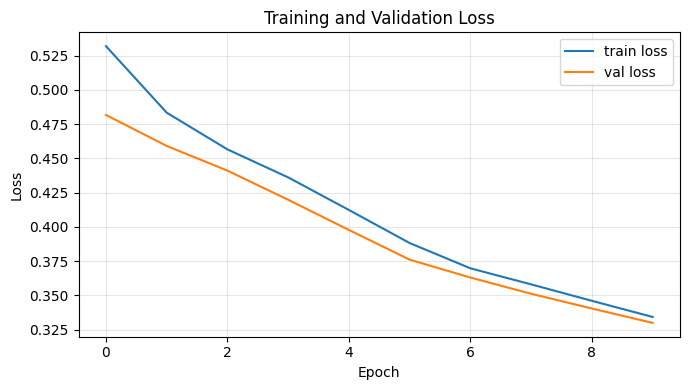

In [ ]:
# Loss Curve
history_df = pd.DataFrame(history.history)

plt.figure(figsize=(7, 4))
plt.plot(history_df["loss"], label="train loss")
plt.plot(history_df["val_loss"], label="val loss")
plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "loss_curve.png"), dpi=150)
plt.show()

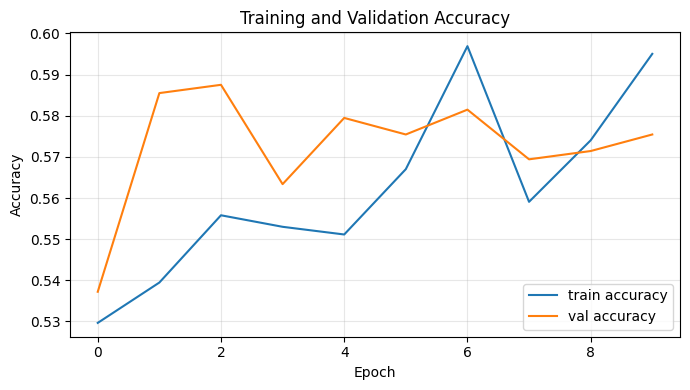

In [ ]:
# Accuracy Curve
plt.figure(figsize=(7, 4))
plt.plot(history_df["accuracy"], label="train accuracy")
plt.plot(history_df["val_accuracy"], label="val accuracy")
plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "accuracy_curve.png"), dpi=150)
plt.show()

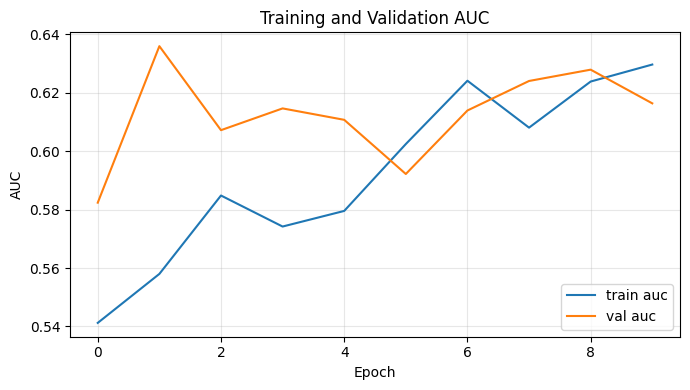

In [ ]:
# ROC-AUC curve
plt.figure(figsize=(7, 4))
plt.plot(history_df["auc"], label="train auc")
plt.plot(history_df["val_auc"], label="val auc")
plt.title("Training and Validation AUC")
plt.xlabel("Epoch")
plt.ylabel("AUC")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "auc_curve.png"), dpi=150)
plt.show()

In [ ]:
# Threshold tuning
val_prob = model.predict(X_val, verbose=0).ravel()
thresholds = np.round(np.arange(0.05, 0.96, 0.01), 2)

pred_matrix = (val_prob[:, None] >= thresholds[None, :]).astype("int32")
truth_matrix = y_val[:, None]

tp = ((pred_matrix == 1) & (truth_matrix == 1)).sum(axis=0)
tn = ((pred_matrix == 0) & (truth_matrix == 0)).sum(axis=0)
fp = ((pred_matrix == 1) & (truth_matrix == 0)).sum(axis=0)
fn = ((pred_matrix == 0) & (truth_matrix == 1)).sum(axis=0)

precision_values = tp / np.maximum(tp + fp, 1)
recall_values = tp / np.maximum(tp + fn, 1)
specificity_values = tn / np.maximum(tn + fp, 1)
accuracy_values = (tp + tn) / np.maximum(tp + tn + fp + fn, 1)
balanced_values = (recall_values + specificity_values) / 2
f1_values = 2 * precision_values * recall_values / np.maximum(precision_values + recall_values, 1e-8)

threshold_table = pd.DataFrame({
    "threshold": thresholds,
    "accuracy": accuracy_values,
    "balanced_accuracy": balanced_values,
    "precision": precision_values,
    "recall": recall_values,
    "specificity": specificity_values,
    "f1_score": f1_values
})

In [ ]:
best_f1_threshold = float(threshold_table.loc[threshold_table["f1_score"].idxmax(), "threshold"])
best_balanced_threshold = float(threshold_table.loc[threshold_table["balanced_accuracy"].idxmax(), "threshold"])

threshold_table.to_csv(os.path.join(OUTPUT_DIR, "validation_threshold_table.csv"), index=False)

In [ ]:
print("best f1 threshold:", best_f1_threshold)
print("best balanced threshold:", best_balanced_threshold)
print(threshold_table.sort_values("f1_score", ascending=False).head(10).round(4))

best f1 threshold: 0.47
best balanced threshold: 0.48
    threshold  accuracy  balanced_accuracy  precision  recall  specificity  \
42       0.47    0.5895             0.6046     0.5401  0.8632       0.3460   
40       0.45    0.5412             0.5632     0.5069  0.9402       0.1863   
39       0.44    0.5292             0.5530     0.5000  0.9615       0.1445   
38       0.43    0.5171             0.5421     0.4935  0.9701       0.1141   
37       0.42    0.5091             0.5345     0.4892  0.9701       0.0989   
41       0.46    0.5433             0.5630     0.5084  0.9017       0.2243   
43       0.48    0.6197             0.6268     0.5738  0.7479       0.5057   
36       0.41    0.4970             0.5235     0.4831  0.9786       0.0684   
35       0.40    0.4930             0.5200     0.4812  0.9829       0.0570   
34       0.39    0.4849             0.5124     0.4772  0.9829       0.0418   

    f1_score  
42    0.6645  
40    0.6587  
39    0.6579  
38    0.6542  
37    0.6504

In [ ]:
# Final test evaluation
test_prob = model.predict(X_test, verbose=0).ravel()
test_pred = (test_prob >= best_f1_threshold).astype("int32")

final_metrics = pd.DataFrame({
    "metric": [
        "accuracy",
        "balanced_accuracy",
        "precision",
        "recall",
        "f1_score",
        "roc_auc",
        "threshold"
    ],
    "value": [
        accuracy_score(y_test, test_pred),
        balanced_accuracy_score(y_test, test_pred),
        precision_score(y_test, test_pred, zero_division=0),
        recall_score(y_test, test_pred, zero_division=0),
        f1_score(y_test, test_pred, zero_division=0),
        roc_auc_score(y_test, test_prob),
        best_f1_threshold
    ]
})

In [ ]:
final_metrics.to_csv(os.path.join(OUTPUT_DIR, "final_test_metrics.csv"), index=False)
print(final_metrics.round(4).to_string(index=False))

           metric  value
         accuracy 0.5840
balanced_accuracy 0.5671
        precision 0.5807
           recall 0.8039
         f1_score 0.6743
          roc_auc 0.6023
        threshold 0.4700


In [ ]:
cm = confusion_matrix(y_test, test_pred)
cm_df = pd.DataFrame(cm, index=["Actual Non-Nodule", "Actual Nodule"], columns=["Predicted Non-Nodule", "Predicted Nodule"])
cm_df.to_csv(os.path.join(OUTPUT_DIR, "confusion_matrix.csv"))
cm_df

,Predicted Non-Nodule,Predicted Nodule
Actual Non-Nodule,73,148
Actual Nodule,50,205


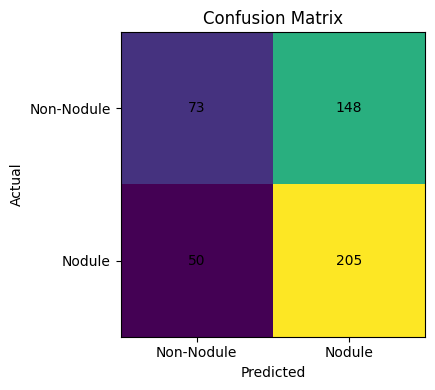

In [ ]:
# Evaluation plots
plt.figure(figsize=(5, 4))
plt.imshow(cm, interpolation="nearest")
plt.title("Confusion Matrix")
plt.xticks([0, 1], ["Non-Nodule", "Nodule"])
plt.yticks([0, 1], ["Non-Nodule", "Nodule"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.text(0, 0, cm[0, 0], ha="center", va="center")
plt.text(1, 0, cm[0, 1], ha="center", va="center")
plt.text(0, 1, cm[1, 0], ha="center", va="center")
plt.text(1, 1, cm[1, 1], ha="center", va="center")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "confusion_matrix.png"), dpi=150)
plt.show()

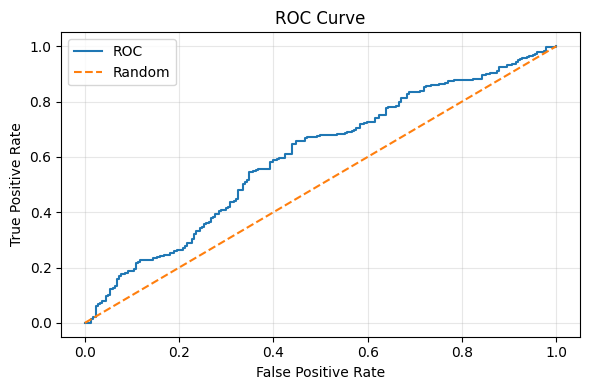

In [ ]:
fpr, tpr, roc_thresholds = roc_curve(y_test, test_prob)
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label="ROC")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random")
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "roc_curve.png"), dpi=150)
plt.show()

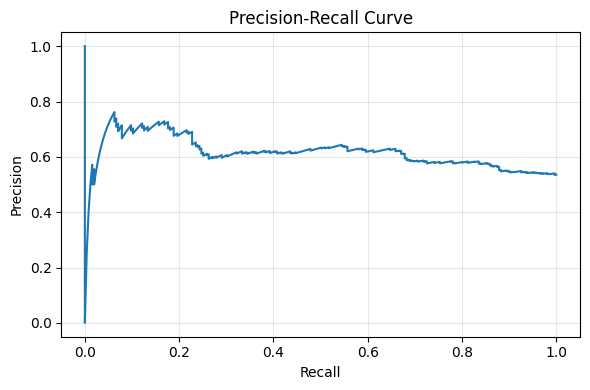

In [ ]:
pr_precision, pr_recall, pr_thresholds = precision_recall_curve(y_test, test_prob)
plt.figure(figsize=(6, 4))
plt.plot(pr_recall, pr_precision)
plt.title("Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "precision_recall_curve.png"), dpi=150)
plt.show()

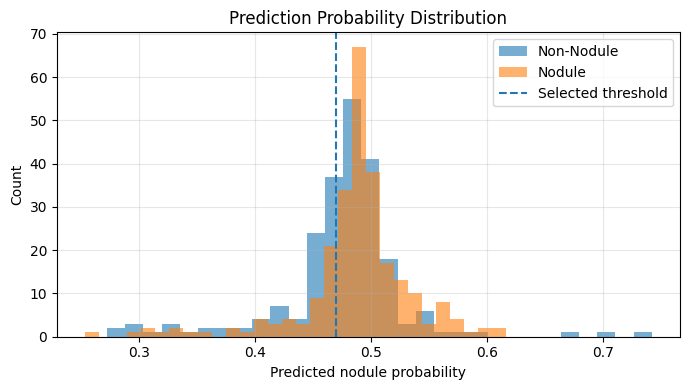

In [ ]:
plt.figure(figsize=(7, 4))
plt.hist(test_prob[y_test == 0], bins=30, alpha=0.6, label="Non-Nodule")
plt.hist(test_prob[y_test == 1], bins=30, alpha=0.6, label="Nodule")
plt.axvline(best_f1_threshold, linestyle="--", label="Selected threshold")
plt.title("Prediction Probability Distribution")
plt.xlabel("Predicted nodule probability")
plt.ylabel("Count")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "probability_distribution.png"), dpi=150)
plt.show()

In [ ]:
# Save prediction samples
test_rows = model_df.iloc[test_idx].copy()
test_rows["new_probability"] = test_prob
test_rows["new_prediction"] = test_pred

cols_to_save = ["seriesuid", "coordX", "coordY", "coordZ", "class", "new_probability", "new_prediction"]
test_rows[cols_to_save].to_csv(os.path.join(OUTPUT_DIR, "test_predictions.csv"), index=False)

print(test_rows[["coordX", "coordY", "coordZ", "class", "new_probability", "new_prediction"]].head(12).round(4).to_string(index=False))

  coordX    coordY    coordZ  class  new_probability  new_prediction
 45.4406  -33.9706 -141.5571      1           0.4979               1
-58.8383  181.0842 1694.5963      0           0.3711               0
-37.2909 -118.2139  841.4883      0           0.3259               0
 53.1900   35.1700  -75.4100      0           0.4798               1
 64.4547   43.7935 -236.0111      1           0.4829               1
 59.0400 -109.2300 -116.5600      0           0.4818               1
 76.7200   51.6300 -234.5800      0           0.5001               1
-72.0300  -13.1100 -169.6600      0           0.4719               1
 76.1494   72.0105  -96.6500      1           0.4936               1
 85.2200 -206.4300  167.1900      1           0.4840               1
-71.0172   20.3316  -23.5627      1           0.4944               1
-93.5500  -49.5700 -148.1200      1           0.4889               1


In [ ]:
# Save model files
model.save(os.path.join(OUTPUT_DIR, "milestone4_candidate_densenet.keras"))

config = {
    "model_name": "Milestone4_Balanced_DenseNet",
    "dataset": "LUNA16 candidates_V2.csv",
    "input_features": feature_cols,
    "polynomial_features": True,
    "threshold": best_f1_threshold,
    "target_classes": {
        "0": "Non-Nodule",
        "1": "Nodule"
    }
}

with open(os.path.join(OUTPUT_DIR, "model_config.json"), "w") as f:
    json.dump(config, f, indent=4)

print("model saved")
print("output folder:", OUTPUT_DIR)

model saved
output folder: /content/luna16_milestone4_output
